# 04 · Model training

Reads `data/processed/runs/<run>/model_input.pkl` from `03_data_preparation.ipynb` and trains every model the protocol compares:

| model | role |
|---|---|
| guideline calendar schedule | comparator: what is done today (echo at 5 and 10 years, then yearly) |
| valve age only | comparator: risk from time since implant alone |
| Cox on published risk factors | comparator and hazard-ratio table for clinicians |
| discrete-time competing-risks regression | clinical baseline with proper cumulative incidence |
| discrete-time competing-risks gradient boosting | primary model |
| the two discrete-time models, recalibrated | same models with a calibration step fitted on training patients only |

All models predict the cumulative incidence of SVD at 2, 5 and 8 years from a landmark, with death as a competing event. The data are **synthetic** unless notebook 03 was run on the extract; the label is printed on every output.

Code: `pipeline/ml.py`. Scoring on the real extract (calibration, decision curve, risk tiers, subgroups) follows in `05_results.ipynb`.

## 0. Settings

In [1]:
from pathlib import Path
import os, sys, importlib, pickle, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "notebooks"))
from pipeline import viz, ml
for m in (viz, ml):
    importlib.reload(m)
viz.use_style()

PROCESSED = ROOT / "data" / "processed"
RUN = os.environ.get("AVR_RUN", "main")
RUN_DIR = PROCESSED / "runs" / RUN
MODELS = RUN_DIR / "models"
MODELS.mkdir(parents=True, exist_ok=True)
bundle = pickle.loads((RUN_DIR / "model_input.pkl").read_bytes())
X, meta, train, test = bundle["X"], bundle["meta"], bundle["train"], bundle["test"]
FEATURES = bundle["features_used"]
PRIORS = [f for f in FEATURES if ml.FEATURES[f]["prior"]]
HORIZONS = tuple(bundle["labels"]["horizons"])
H = max(HORIZONS)
LABEL = bundle["label"]
TUNE = True
GRID = dict(learning_rate=[0.03, 0.1], max_leaf_nodes=[7, 15, 31], min_samples_leaf=[20, 80])
CV_FOLDS = 3
TUNE_HORIZON = 5
RECAL_METHOD = "platt"
pd.Series({"data": LABEL, "landmark rows (train / test)": f"{train.sum()} / {test.sum()}", "features used": len(FEATURES),
           "clinical priors": ", ".join(PRIORS), "feature selection applied": bundle["selection"]["enabled"], "horizons": HORIZONS,
           "split": f"implant year up to {bundle['split_year']} vs after"}, name="value").to_frame()

,value
data,"synthetic, matched to real extract"
landmark rows (train / test),15879 / 5868
features used,8
clinical priors,"landmark_years, tavr, valve_size_mm, ref_mg, d..."
feature selection applied,True
horizons,"(2, 5, 8)"
split,implant year up to 2018 vs after


## 1. Comparators

**Guideline calendar schedule.** Current practice treats every valve the same until it is five years old and then watches it more closely. As a risk score that means two groups, valves under and over five years at the landmark, each given the cumulative incidence observed in the training set for its group.

**Valve age only.** A boosted model with time since implant as its only input. Any model worth deploying has to beat both.

**Cox on published risk factors.** A cause-specific Cox model for SVD on the landmark rows, fitted with `lifelines`, with the clinical priors as covariates and robust standard errors clustered by patient (each patient contributes several rows). It gives clinicians hazard ratios. Its risk at a horizon is one minus the SVD-free survival, which ignores death and so overstates absolute risk; it is used for ranking, and the regression below gives the calibrated equivalent.

In [2]:
calendar = ml.CalendarSchedule(horizon=H).fit(X[train], meta[train])
time_only = ml.DiscreteTimeCompetingRisks(["landmark_years"], kind="gbm", horizon=H).fit(X[train], meta[train])
pd.DataFrame({g: calendar.cif_[g] for g in (False, True)}).rename(columns={False: "valve under 5 years", True: "valve 5 years or older"}).loc[list(HORIZONS)].map("{:.1%}".format).rename_axis("years after landmark")

,valve under 5 years,valve 5 years or older
years after landmark,,
2,1.7%,5.6%
5,7.3%,16.7%
8,17.7%,16.7%


In [3]:
t0 = time.time()
cox = ml.CoxRiskFactors(PRIORS, horizon=H).fit(X[train], meta[train])
hr = cox.model_.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
hr.columns = ["hazard ratio", "lower 95%", "upper 95%", "p"]
hr["per"] = ["year" if f in ("landmark_years", "age_at_implant") else "mm" if f == "valve_size_mm" else "mmHg" if f in ("ref_mg", "delta_mg") else "grade" if f == "ppm_grade" else "yes vs no" for f in hr.index]
print(f"fitted in {time.time() - t0:.1f}s, concordance {cox.model_.concordance_index_:.3f} (training rows, {LABEL})")
hr.round(3)

fitted in 0.9s, concordance 0.703 (training rows, synthetic, matched to real extract)


,hazard ratio,lower 95%,upper 95%,p,per
covariate,,,,,
landmark_years,1.178,1.129,1.229,0.000,year
tavr,0.831,0.695,0.994,0.043,yes vs no
valve_size_mm,0.994,0.965,1.023,0.679,mm
ref_mg,1.001,0.969,1.035,0.937,mmHg
delta_mg,1.225,0.979,1.533,0.075,mmHg


## 2. Clinical baseline: discrete-time competing-risks regression

Two logistic models on the person-period rows, one for the yearly SVD hazard and one for the yearly death hazard, each with a separate intercept per follow-up year. At yearly resolution this is the discrete-time form of the cause-specific Cox model (Cox 1972, for tied event times). The cumulative incidence at h years chains the two hazards, so death is never treated as censoring. Inputs are the clinical priors only; missing values are median-filled with an indicator.

**Person-years.** Follow-up times are rounded to 0.01 years before being cut into yearly intervals, so a time stored as 2.999 (days divided by 365.25) counts as three full years and not two. A valve censored part-way through a year contributes that year with a weight equal to the share observed (the actuarial convention). Before this fix, nearly complete censored years were thrown away while events in the same years were kept, and every model overstated risk: the valve-age model predicted 40 percent 5-year SVD on training rows whose observed incidence was 25 percent.

In [4]:
t0 = time.time()
baseline = ml.DiscreteTimeCompetingRisks(PRIORS, kind="logit", horizon=H).fit(X[train], meta[train])
coef = pd.Series(baseline.svd_[-1].coef_[0], index=baseline.svd_[:-1].get_feature_names_out() if hasattr(baseline.svd_[:-1], "get_feature_names_out") else None)
odds = np.exp(coef).rename("odds ratio per SD").to_frame()
odds = odds[~odds.index.str.startswith(("interval_", "missingindicator"))]
print(f"fitted in {time.time() - t0:.1f}s on {baseline.n_rows_} person-years ({baseline.n_events_['svd']} SVD, {baseline.n_events_['death']} deaths)")
odds.round(2)

fitted in 0.0s on 50856 person-years (802 SVD, 0 deaths)


,odds ratio per SD
landmark_years,1.78
tavr,0.82
valve_size_mm,1.01
ref_mg,1.04
delta_mg,1.09


## 3. Primary model: discrete-time competing-risks gradient boosting

The same two-hazard structure with gradient-boosted trees (`HistGradientBoostingClassifier`). Missing values are handled natively, and the SVD model is constrained so predicted risk can only move in the direction the literature supports (for example, a higher gradient change never lowers risk). The death model is unconstrained.

**Inputs.** The fixed clinical feature list from notebook 03 (automatic selection is optional there). The surveillance block (how often and how recently a valve was imaged) is never used: kept in, those process features let the boosted model learn surveillance patterns instead of valve biology.

**Tuning.** A small grid over learning rate, tree size and leaf size, scored by the competing-risk AUC at five years in cross-validation on the training patients (folds split by patient, never by row). Early stopping inside each fit sets the number of trees.

In [5]:
from itertools import product
from sklearn.model_selection import GroupKFold

def cv_score(params, folds=CV_FOLDS, h=TUNE_HORIZON):
    Xt, mt = X[train].reset_index(drop=True), meta[train].reset_index(drop=True)
    scores = []
    for fit_idx, val_idx in GroupKFold(n_splits=folds).split(Xt, groups=mt.patient_id):
        m = ml.DiscreteTimeCompetingRisks(FEATURES, kind="gbm", horizon=H, **params).fit(Xt.iloc[fit_idx], mt.iloc[fit_idx])
        p = m.predict_cif(Xt.iloc[val_idx])[f"svd_{h}y"]
        scores.append(ml.cr_auc(p, mt.time_to_end.iloc[val_idx], mt.status.iloc[val_idx], h))
    return np.mean(scores), np.std(scores)

results = []
if TUNE:
    t0 = time.time()
    for values in product(*GRID.values()):
        params = dict(zip(GRID, values))
        mean, sd = cv_score(params)
        results.append({**params, "cv AUC": mean, "sd": sd})
    tuning = pd.DataFrame(results).sort_values("cv AUC", ascending=False)
    best = tuning.iloc[0][list(GRID)].to_dict()
    best = {k: (int(v) if k != "learning_rate" else float(v)) for k, v in best.items()}
    print(f"{len(results)} settings x {CV_FOLDS} folds in {time.time() - t0:.0f}s; best {best}")
    display(tuning.head(6).round(3))
else:
    best = {}

12 settings x 3 folds in 36s; best {'learning_rate': 0.03, 'max_leaf_nodes': 7, 'min_samples_leaf': 20}


,learning_rate,max_leaf_nodes,min_samples_leaf,cv AUC,sd
0,0.03,7,20,0.703,0.071
1,0.03,7,80,0.703,0.067
7,0.10,7,80,0.696,0.071
3,0.03,15,80,0.694,0.066
2,0.03,15,20,0.694,0.067
8,0.10,15,20,0.693,0.062


In [6]:
t0 = time.time()
primary = ml.DiscreteTimeCompetingRisks(FEATURES, kind="gbm", horizon=H, **best).fit(X[train], meta[train])
unconstrained = ml.DiscreteTimeCompetingRisks(FEATURES, kind="gbm", horizon=H, monotone=False, **best).fit(X[train], meta[train])
baseline_recal = ml.RecalibratedModel(ml.DiscreteTimeCompetingRisks(PRIORS, kind="logit", horizon=H), method=RECAL_METHOD).fit(X[train], meta[train])
primary_recal = ml.RecalibratedModel(ml.DiscreteTimeCompetingRisks(FEATURES, kind="gbm", horizon=H, **best), method=RECAL_METHOD).fit(X[train], meta[train])
display(pd.DataFrame({n: dict(zip(["intercept", "slope"], m.params_["svd"])) for n, m in [("regression baseline", baseline_recal), ("gradient boosting", primary_recal)]}).T.round(3).rename_axis("SVD hazard recalibration"))
pd.Series({"fit time (s)": round(time.time() - t0, 1), "SVD trees": primary.svd_.n_iter_, "death trees": primary.death_.n_iter_ if primary.death_ else 0,
           "person-years": primary.n_rows_, "SVD events": primary.n_events_["svd"], "deaths": primary.n_events_["death"]}, name="primary model").to_frame()

,intercept,slope
SVD hazard recalibration,,
regression baseline,-0.536,0.862
gradient boosting,-0.873,0.764


,primary model
fit time (s),9.8
SVD trees,332.0
death trees,0.0
person-years,50856.0
SVD events,802.0
deaths,0.0


### Recalibration

`ml.RecalibratedModel` wraps either discrete-time model. It fits the model on two thirds of the training patients, predicts the yearly SVD hazard for the remaining third, and repeats this three times, so every training patient gets an out-of-fold prediction. A weighted logistic model of the observed yearly event on the logit of that hazard gives an intercept and a slope (`RECAL_METHOD = "platt"`; `"intercept"` fixes the slope at 1). The model is then refitted on all training patients and its hazards are adjusted before the cumulative incidence is built. A slope below 1 means the raw model spreads its risks too far. The real extract is never used, so this corrects the model's own miscalibration, not a difference between the training cohort and the hospital.

### How much data the primary model needs

The primary model refitted on growing shares of the training patients and scored in the same cross-validation. A curve still rising at 100 percent says more patients would help; a flat one says the features, not the sample, are the limit.

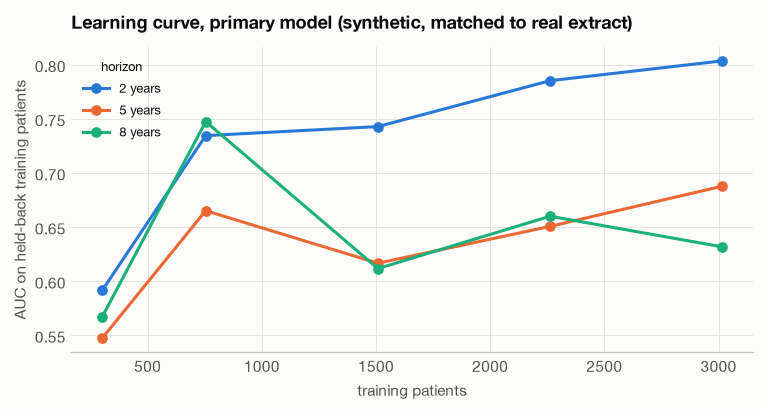

,share,patients,events,AUC 2y,AUC 5y,AUC 8y
0,0.10,301,40,0.592,0.548,0.567
1,0.25,754,156,0.735,0.665,0.748
2,0.50,1508,242,0.743,0.617,0.612
3,0.75,2262,445,0.785,0.651,0.660
4,1.00,3016,566,0.804,0.688,0.632


In [7]:
rng = np.random.default_rng(0)
patients = meta.patient_id[train].unique()
val_patients = set(rng.choice(patients, len(patients) // 4, replace=False))
is_val = meta.patient_id.isin(val_patients).to_numpy() & train
pool = [p for p in patients if p not in val_patients]
curve = []
for share in [0.1, 0.25, 0.5, 0.75, 1.0]:
    pick = set(rng.choice(pool, int(len(pool) * share), replace=False))
    fit_rows = meta.patient_id.isin(pick).to_numpy() & train
    m = ml.DiscreteTimeCompetingRisks(FEATURES, kind="gbm", horizon=H, **best).fit(X[fit_rows], meta[fit_rows])
    p = m.predict_cif(X[is_val])
    curve.append(dict(share=share, patients=len(pick), events=m.n_events_["svd"],
                      **{f"AUC {h}y": ml.cr_auc(p[f"svd_{h}y"], meta.time_to_end[is_val], meta.status[is_val], h) for h in HORIZONS}))
curve = pd.DataFrame(curve)
fig, ax = plt.subplots(figsize=(8, 3.6))
for i, h in enumerate(HORIZONS):
    ax.plot(curve.patients, curve[f"AUC {h}y"], marker="o", markersize=6, color=viz.SERIES[i], label=f"{h} years")
ax.set_xlabel("training patients")
ax.set_ylabel("AUC on held-back training patients")
ax.legend(title="horizon", fontsize=8.5, title_fontsize=8.5)
ax.set_title(f"Learning curve, primary model ({LABEL})")
viz.save(fig, "04_learning_curve")
plt.show()
curve.round(3)

## 4. First check on the test valves

Competing-risk time-dependent AUC and Brier score (inverse probability of censoring weights; cases have SVD by the horizon, controls are event-free at the horizon or died first) on valves implanted after the split year, next to the mean predicted risk and the observed cumulative incidence. Calibration curves, decision curves and the ladder are in the evaluation step.

In [8]:
models = {"calendar schedule": calendar, "valve age only": time_only, "Cox, risk factors": cox, "regression baseline": baseline,
          "gradient boosting": primary, "gradient boosting, no constraints": unconstrained,
          "regression baseline, recalibrated": baseline_recal, "gradient boosting, recalibrated": primary_recal}
G = ml.censoring_survival(meta.time_to_end[test], meta.status[test])
predictions, rows = {}, {}
for name, model in models.items():
    cif = model.predict_cif(X[test])
    predictions[name] = cif
    for h in HORIZONS:
        p = cif[f"svd_{h}y"]
        rows[(name, h)] = {"AUC": ml.cr_auc(p, meta.time_to_end[test], meta.status[test], h, G),
                           "Brier": ml.cr_brier(p, meta.time_to_end[test], meta.status[test], h, G),
                           "mean predicted": p.mean()}
observed = {h: ml.aalen_johansen(meta.time_to_end[test], meta.status[test], h) for h in HORIZONS}
perf = pd.DataFrame(rows).T.rename_axis(["model", "horizon"])
table = perf.unstack("horizon")
display(table.style.format("{:.3f}").format("{:.1%}", subset=[c for c in table.columns if c[0] == "mean predicted"]))
pd.Series({f"{h} years": f"{v:.1%}" for h, v in observed.items()}, name=f"observed SVD, Aalen-Johansen ({LABEL}, test valves)").to_frame()

,"observed SVD, Aalen-Johansen (synthetic, matched to real extract, test valves)"
2 years,1.7%
5 years,7.2%
8 years,18.5%


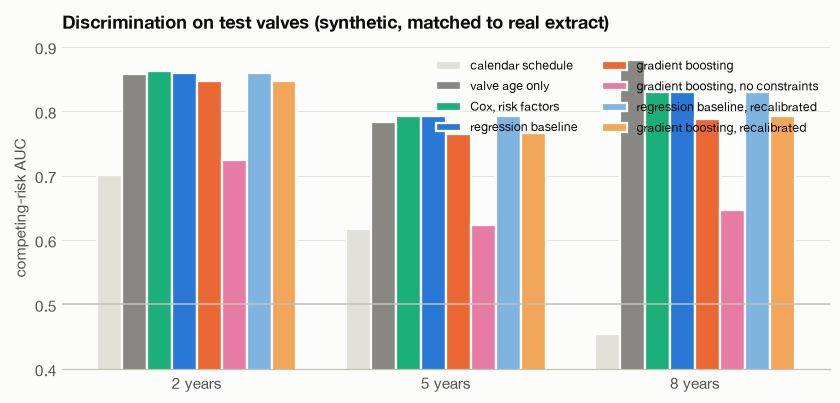

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.8))
names = list(models)
x = np.arange(len(HORIZONS))
width = 0.8 / len(names)
palette = [viz.GRID, viz.MUTED, viz.SERIES[2], viz.SERIES[0], viz.SERIES[1], "#e87ba4", "#7fb3e0", "#f2a65a"]
for i, name in enumerate(names):
    vals = [perf.loc[(name, h), "AUC"] for h in HORIZONS]
    ax.bar(x + (i - (len(names) - 1) / 2) * width, vals, width=width, color=palette[i], edgecolor=viz.SURFACE, linewidth=1.5, label=name)
ax.axhline(0.5, color=viz.AXIS, linewidth=1)
ax.set_xticks(x, [f"{h} years" for h in HORIZONS])
ax.set_ylim(0.4, 0.9)
ax.set_ylabel("competing-risk AUC")
ax.grid(axis="x", visible=False)
ax.legend(fontsize=8, ncol=2, loc="upper right")
ax.set_title(f"Discrimination on test valves ({LABEL})")
viz.save(fig, "04_auc_by_model")
plt.show()

**What the test valves show (synthetic cohort matched to the real extract, fixed feature list, surveillance block dropped).**

- Valve age still carries most of the signal. At 5 years the regression baseline and Cox rank best (AUC 0.79; 0.86, 0.79 and 0.83 at 2, 5 and 8 years), with valve age alone close behind (0.86, 0.78, 0.88) and the constrained boosted model just below it (0.85, 0.77, 0.79). Without monotone constraints the boosted model drops to 0.62 at 5 years, so the constraints earn their place.
- Calibration is close: observed 5-year incidence is 7.2 percent and the risk models predict 7.6 to 10.2 percent.
- Recalibration on out-of-fold training predictions barely moves the ranking, and brings the boosted model's 8-year prediction from 18.8 to 17.4 percent against 18.5 observed.

## 5. What drives the primary model

SHAP values for the yearly SVD hazard of the primary model, on test rows in the first year after the landmark. Positive values raise the predicted hazard.

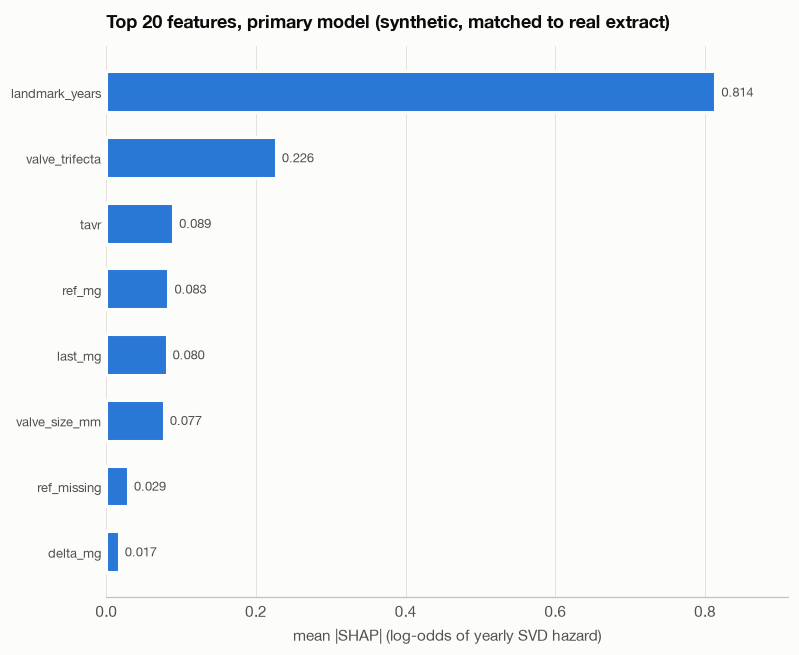

,mean |SHAP|,value vs SHAP correlation,expected direction
landmark_years,0.814,0.973,1
valve_trifecta,0.226,0.914,0
tavr,0.089,-0.733,0
ref_mg,0.083,0.690,1
last_mg,0.080,0.480,1
valve_size_mm,0.077,-0.592,-1
ref_missing,0.029,0.111,0
delta_mg,0.017,0.628,1


In [10]:
import shap
sample = X[test].sample(min(1500, int(test.sum())), random_state=0)
design = primary._design(sample[FEATURES].reset_index(drop=True).assign(interval=1))
explainer = shap.TreeExplainer(primary.svd_)
values = explainer.shap_values(design)
importance = pd.Series(np.abs(values).mean(axis=0), index=design.columns).drop("interval").sort_values(ascending=False)
top = importance.head(20)
fig, ax = plt.subplots(figsize=(8, 6.5))
viz.hbar(ax, list(top.index), list(top.values), value_fmt="{:.3f}", xlabel="mean |SHAP| (log-odds of yearly SVD hazard)")
ax.tick_params(axis="y", labelsize=8.5)
ax.set_title(f"Top 20 features, primary model ({LABEL})")
viz.save(fig, "04_shap_importance")
plt.show()
agree = {}
for f in top.index:
    col = list(design.columns).index(f)
    ok = design[f].notna().to_numpy()
    agree[f] = np.corrcoef(design[f][ok], values[ok, col])[0, 1] if design[f][ok].nunique() > 1 else np.nan
pd.DataFrame({"mean |SHAP|": top, "value vs SHAP correlation": pd.Series(agree), "expected direction": [ml.FEATURES[f]["direction"] for f in top.index]}).round(3)

### One prediction, as a clinician would see it

A test valve at a follow-up visit: its predicted SVD risk at each horizon, the risk tier, the echo interval that tier maps to, and the three features that moved its risk most.

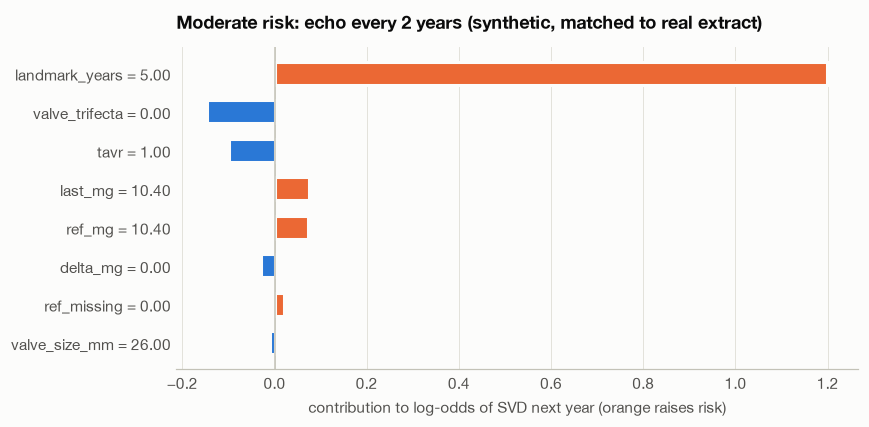

,prediction
SVD within 2 years,3.2%
SVD within 5 years,15.0%
SVD within 8 years,37.7%
risk tier (5-year risk),moderate
recommended echo interval,echo every 2 years
main reasons,landmark years raises risk; valve trifecta low...
valve age at this visit,5 years


In [11]:
cif_test = predictions["gradient boosting"]
row = cif_test["svd_5y"].sub(0.15).abs().idxmin()
one = X.loc[[row], FEATURES]
d1 = primary._design(one.reset_index(drop=True).assign(interval=1))
contrib = pd.Series(explainer.shap_values(d1)[0], index=d1.columns).drop("interval")
top8 = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(8)
tier, action = ml.risk_tier(cif_test.loc[row, "svd_5y"])
fig, ax = plt.subplots(figsize=(8, 3.8))
labels = [f"{f} = {one.iloc[0][f]:.2f}" if pd.notna(one.iloc[0][f]) else f"{f} = missing" for f in top8.index]
ax.barh(labels, top8.values, color=[viz.SERIES[1] if v > 0 else viz.SERIES[0] for v in top8.values], height=0.6, edgecolor=viz.SURFACE, linewidth=2)
ax.axvline(0, color=viz.AXIS, linewidth=1)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("contribution to log-odds of SVD next year (orange raises risk)")
ax.set_title(f"{tier.capitalize()} risk: {action} ({LABEL})")
viz.save(fig, "04_single_prediction")
plt.show()
words = [f"{f.replace('_', ' ')} {'raises' if v > 0 else 'lowers'} risk" for f, v in top8.head(3).items()]
pd.Series({**{f"SVD within {h} years": f"{cif_test.loc[row, f'svd_{h}y']:.1%}" for h in HORIZONS}, "risk tier (5-year risk)": tier,
           "recommended echo interval": action, "main reasons": "; ".join(words), "valve age at this visit": f"{meta.loc[row, 'landmark_years']:g} years"}, name="prediction").to_frame()

In [12]:
tiers = cif_test["svd_5y"].map(lambda p: ml.risk_tier(p)[0])
by_tier = pd.DataFrame({"test rows": tiers.value_counts(), "mean 5-year risk": cif_test["svd_5y"].groupby(tiers).mean().map("{:.1%}".format)}).reindex([t[1] for t in ml.RISK_TIERS])
by_tier["threshold"] = ["under 5%", "5 to 15%", "15% or more"]
by_tier["action"] = [t[2] for t in ml.RISK_TIERS]
by_tier

,test rows,mean 5-year risk,threshold,action
svd_5y,,,,
low,2791,3.5%,under 5%,guideline schedule
moderate,2378,8.4%,5 to 15%,echo every 2 years
high,699,22.4%,15% or more,echo every year


## 6. The trained models on the real extract

The real extract, prepared by `02_preprocessing.ipynb` and converted by `landmarks.from_preprocessing`, run through the same landmark and feature code and scored by the models trained above. Nothing is refitted: every real landmark row is test data.

What to expect before looking at the numbers: one row per valve, dates to the year, age missing for everyone, echo values for a minority of rows, no deaths recorded (so the competing risk never fires), and only structural events that the provisional rule accepted, nine of the ten of them reinterventions. Few events means wide uncertainty, so a patient-level bootstrap interval is shown for the 5-year AUC. Only counts and metrics are printed.

In [13]:
REAL = Path(os.environ.get("AVR_REAL_DIR", ROOT / "data" / "processed"))
real_available = (REAL / "implants.parquet").exists()
if not real_available:
    print("Real extract not prepared on this machine: run 02_preprocessing.ipynb first. Section skipped.")
else:
    from pipeline import landmarks
    importlib.reload(landmarks)
    real_tables = landmarks.from_preprocessing(REAL)
    real_lm, real_outcomes = landmarks.build_landmark_table(real_tables, bundle["labels"])
    Xr, mr = ml.feature_matrix(real_lm)
    Xr = Xr.reindex(columns=X.columns)
    display(pd.Series({
        "valves with a known implant year": len(real_outcomes),
        "valves with a structural event": int(real_outcomes.status.eq("svd").sum()),
        "valves scored (followed beyond 6 months)": mr.patient_id.nunique(),
        "landmark rows": len(mr),
        "valves with an event among those scored": mr.patient_id[mr.status.eq("svd")].nunique(),
        "deaths recorded": int(real_outcomes.status.eq("death").sum()),
    }, name="real extract").to_frame())
    availability = Xr.notna().mean()
    display(availability[availability > 0].sort_values(ascending=False).map("{:.0%}".format).rename("share of real rows with a value").to_frame().T)

,real extract
valves with a known implant year,117
valves with a structural event,10
valves scored (followed beyond 6 months),51
landmark rows,301
valves with an event among those scored,10
deaths recorded,0


,landmark_years,n_echo,tavr,male,valve_sapien_3,valve_evolut,valve_trifecta,valve_perimount,valve_epic,valve_magna,...,max_mg,ref_ar,delta_ar,delta_mg,ref_mg,last_peak,ref_peak,last_lvef,ref_lvef,last_dvi
share of real rows with a value,100%,100%,100%,98%,95%,95%,95%,95%,95%,95%,...,14%,12%,12%,11%,11%,10%,8%,6%,4%,2%


In [14]:
if real_available:
    Gr = ml.censoring_survival(mr.time_to_end, mr.status)
    real_rows, real_pred = {}, {}
    for name, model in models.items():
        cif = model.predict_cif(Xr)
        real_pred[name] = cif
        for h in HORIZONS:
            p = cif[f"svd_{h}y"]
            real_rows[(name, h)] = {"AUC": ml.cr_auc(p, mr.time_to_end, mr.status, h, Gr), "Brier": ml.cr_brier(p, mr.time_to_end, mr.status, h, Gr), "mean predicted": p.mean()}
    real_perf = pd.DataFrame(real_rows).T.rename_axis(["model", "horizon"]).unstack("horizon")
    display(real_perf.style.format("{:.3f}").format("{:.1%}", subset=[c for c in real_perf.columns if c[0] == "mean predicted"]))
    display(pd.Series({f"{h} years": f"{ml.aalen_johansen(mr.time_to_end, mr.status, h):.1%}" for h in HORIZONS}, name="observed, Aalen-Johansen (real extract, no deaths recorded)").to_frame())
    rng = np.random.default_rng(0)
    pats = mr.patient_id.unique()
    boot = {n: [] for n in models}
    for _ in range(300):
        idx = np.concatenate([np.flatnonzero(mr.patient_id.to_numpy() == p) for p in rng.choice(pats, len(pats), replace=True)])
        for n in models:
            boot[n].append(ml.cr_auc(real_pred[n]["svd_5y"].to_numpy()[idx], mr.time_to_end.iloc[idx], mr.status.iloc[idx], 5))
    ci = pd.DataFrame({n: {"5-year AUC": real_rows[(n, 5)]["AUC"], "95% interval": "{:.2f} to {:.2f}".format(*np.nanpercentile(v, [2.5, 97.5]))} for n, v in boot.items()}).T
    display(ci.style.format({"5-year AUC": "{:.2f}"}))

,"observed, Aalen-Johansen (real extract, no deaths recorded)"
2 years,5.0%
5 years,16.6%
8 years,34.4%


,5-year AUC,95% interval
calendar schedule,0.65,0.51 to 0.81
valve age only,0.72,0.54 to 0.91
"Cox, risk factors",0.71,0.54 to 0.90
regression baseline,0.72,0.56 to 0.90
gradient boosting,0.67,0.45 to 0.89
"gradient boosting, no constraints",0.66,0.40 to 0.91
"regression baseline, recalibrated",0.72,0.56 to 0.90
"gradient boosting, recalibrated",0.68,0.46 to 0.89


**Reading the real-extract result.** The models were trained where age and serial dated echoes exist. On the extract those inputs are mostly empty, so each model leans on whatever is left, usually valve age. With a handful of events, the bootstrap intervals are wide enough to overlap chance for most models. This is the protocol's argument in numbers: the method needs age at implant and dated serial echoes, which the extract does not supply, and not a different model.

**Real extract, after training on matched data.** 51 valves, 10 with a structural event, no deaths. The regression baseline ranks the real valves best (5-year AUC 0.72, 95% interval 0.56 to 0.90), with valve age alone (0.72) and Cox (0.71) level with it. The constrained boosted model reaches 0.67 (0.45 to 0.89) and the unconstrained one 0.66 (0.40 to 0.91). With 10 events every interval is wide and overlaps the others, so no ranking between the models is established.

Calibration is of the right order: observed 5-year incidence is 16.6 percent, and the risk models predict 11.8 to 17.3 percent on average. The regression baseline is closest (17.3 percent); the others underestimate. Recalibration fitted on training patients cannot close the remaining gap, because it comes from the difference between the training cohort and the hospital, not from the model.

**Which model to present.** On this data, the regression baseline: best on the real extract, simple to explain, and its odds ratios can be checked against the literature. The boosted model stays the protocol's primary model for a cohort with age and serial dated echoes. Here it leans on the latest gradient, which only about one real row in seven has.

## 6. Save

In [15]:
for name, model in {"calendar": calendar, "time_only": time_only, "cox": cox, "baseline": baseline, "primary": primary, "primary_unconstrained": unconstrained,
                    "baseline_recalibrated": baseline_recal, "primary_recalibrated": primary_recal}.items():
    (MODELS / f"{name}.pkl").write_bytes(pickle.dumps(model))
pickle.dump(dict(predictions=predictions, performance=perf, observed=observed, best_params=best, label=LABEL, real_performance=real_perf if real_available else None), open(MODELS / "training_results.pkl", "wb"))
from pipeline import ledger
synthetic_test = {}
for (name, h), r in perf.iterrows():
    synthetic_test.setdefault(name, {})[str(h)] = {k: r[k] for k in r.index}
ledger.update_run_config(RUN_DIR, "training", dict(
    features=FEATURES, priors=PRIORS, horizons=HORIZONS, tuned=TUNE, grid=GRID, cv_folds=CV_FOLDS, tune_horizon=TUNE_HORIZON,
    best_params=best, recalibration=RECAL_METHOD, models=sorted(p.stem for p in MODELS.glob("*.pkl") if p.stem != "training_results"),
    synthetic_test=synthetic_test))
sorted(p.name for p in MODELS.glob("*.pkl"))

['baseline.pkl',
 'baseline_recalibrated.pkl',
 'calendar.pkl',
 'cox.pkl',
 'primary.pkl',
 'primary_recalibrated.pkl',
 'primary_unconstrained.pkl',
 'time_only.pkl',
 'training_results.pkl']